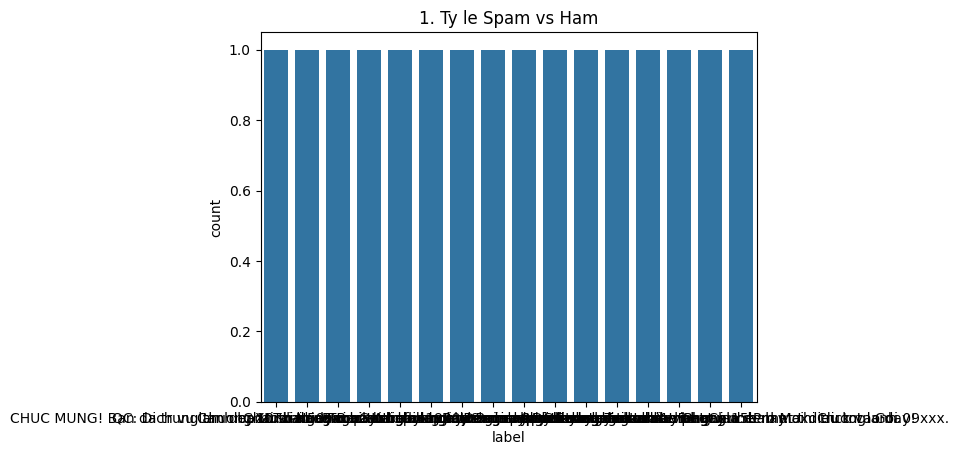

ValueError: We need at least 1 word to plot a word cloud, got 0.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

df = pd.read_csv('data.csv')

# 2. Vẽ biểu đồ tỷ lệ
sns.countplot(x='label', data=df)
plt.title('1. Ty le Spam vs Ham')
plt.show()

# 3. Vẽ WordCloud (Chắc chắn sẽ hiện vì đã có dữ liệu spam ở trên)
spam_words = ' '.join(df[df['label'] == 'spam']['text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(spam_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('2. WordCloud tin nhan Spam')
plt.show()

# 4. Chia dữ liệu & Pipeline
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2)
pipeline_model = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB())
])
pipeline_model.fit(X_train, y_train)

print("--- KẾT QUẢ ---")
print(f"Da chia du lieu: Train({len(X_train)}), Test({len(X_test)})")
print("4. Khung Pipeline da san sang cho tuan sau!")